In [15]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

In [2]:
# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv('/content/Job_2_resource_Weather Test Data.csv')

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (42677, 22)
  row ID Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0   Row0   Albury     12.9     25.7       0.0          NaN       NaN   
1   Row1   Albury      9.2     28.0       0.0          NaN       NaN   
2   Row2   Albury     14.3     25.0       0.0          NaN       NaN   
3   Row3   Albury      9.7     31.9       0.0          NaN       NaN   
4   Row4   Albury     15.9     18.6      15.6          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... WindSpeed3pm  Humidity9am  \
0         WSW           46.0          W  ...         26.0         38.0   
1          NE           24.0         SE  ...          9.0         45.0   
2           W           50.0         SW  ...         24.0         49.0   
3         NNW           80.0         SE  ...         28.0         42.0   
4           W           61.0        NNW  ...         28.0         76.0   

   Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  \
0         30.0       1

In [3]:
# =========================
# 3. Handle Missing Values
# =========================
df = df.fillna(method='ffill')   # simple way

/tmp/ipython-input-49512961.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')   # simple way


In [4]:
# =========================
# 4. Encode Target Variable
# =========================
le = LabelEncoder()
df['RainToday'] = le.fit_transform(df['RainToday'])

In [5]:
# =========================
# 5. Encode All Categorical Columns
# =========================
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

In [6]:
# =========================
# 6. Define Features & Target
# =========================
X = df.drop(['row ID', 'RainToday'], axis=1)
y = df['RainToday']

In [7]:
# =========================
# 7. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# =========================
# 8. Train Model
# =========================
model = LogisticRegression(max_iter=1000)

# Fix: Impute any remaining NaN values in X_train before fitting
# This assumes all features are numerical after prior encoding steps.
X_train_imputed = X_train.fillna(X_train.mean())
model.fit(X_train_imputed, y_train)

LogisticRegression(max_iter=1000)

In [11]:
# =========================
# 9. Predict
# =========================

# Fix: Impute any remaining NaN values in X_test before predicting
# Use the means from the training data for imputation to prevent data leakage.
X_test_imputed = X_test.fillna(X_train.mean())
y_pred = model.predict(X_test_imputed)

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6576
           1       1.00      1.00      1.00      1960

    accuracy                           1.00      8536
   macro avg       1.00      1.00      1.00      8536
weighted avg       1.00      1.00      1.00      8536



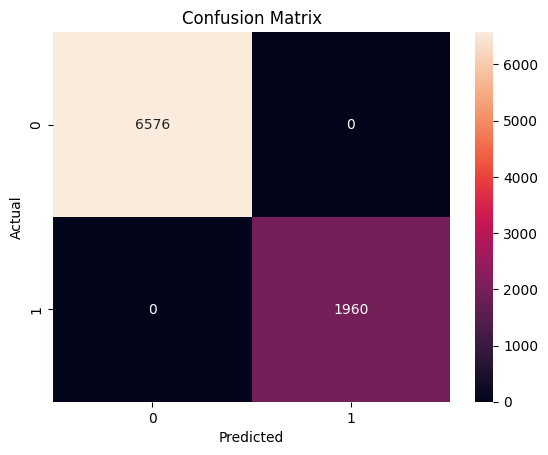

In [12]:
# =========================
# 10. Evaluation
# =========================
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


--- Random Forest Classifier ---
Random Forest Accuracy: 1.0

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6576
           1       1.00      1.00      1.00      1960

    accuracy                           1.00      8536
   macro avg       1.00      1.00      1.00      8536
weighted avg       1.00      1.00      1.00      8536



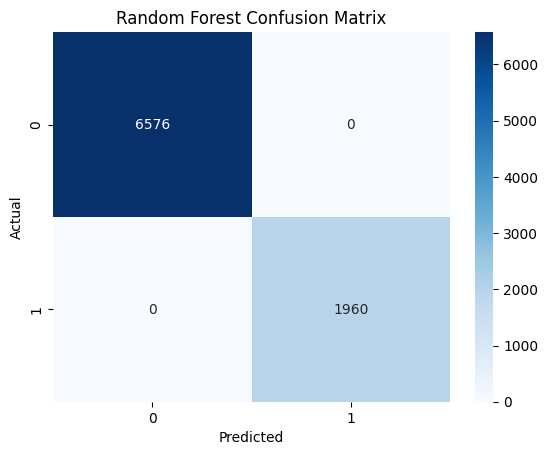

In [14]:
from sklearn.ensemble import RandomForestClassifier

# =========================
# 11. Train Random Forest Model
# =========================
print("\n--- Random Forest Classifier ---")

rf_model = RandomForestClassifier(random_state=42)

# Train the Random Forest model using the imputed training data
rf_model.fit(X_train_imputed, y_train)

# =========================
# 12. Predict with Random Forest
# =========================
rf_y_pred = rf_model.predict(X_test_imputed)

# =========================
# 13. Evaluate Random Forest
# =========================
print("Random Forest Accuracy:", accuracy_score(y_test, rf_y_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))

# Random Forest Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_y_pred)

plt.figure()
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


--- Visualizing Model Performance ---


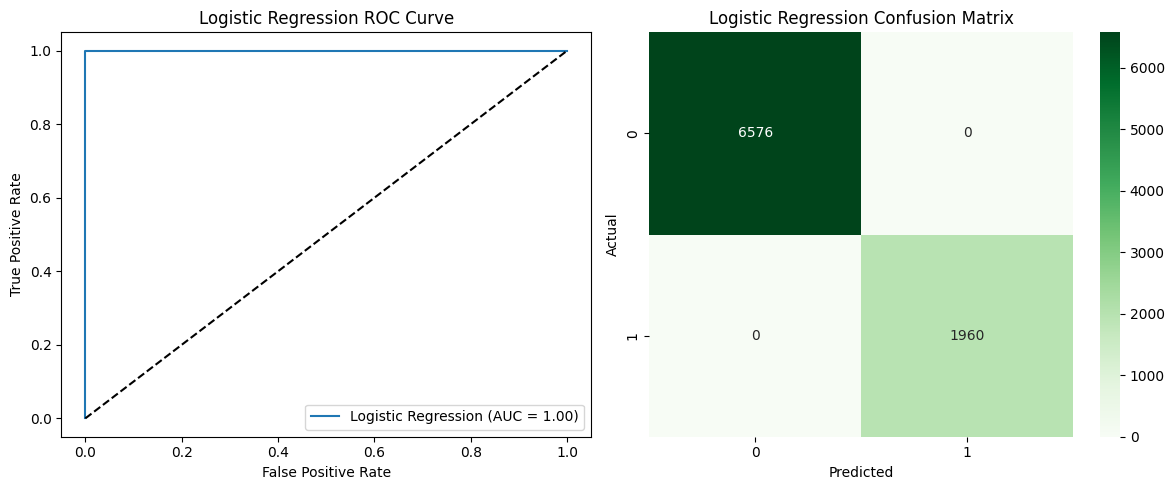


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6576
           1       1.00      1.00      1.00      1960

    accuracy                           1.00      8536
   macro avg       1.00      1.00      1.00      8536
weighted avg       1.00      1.00      1.00      8536



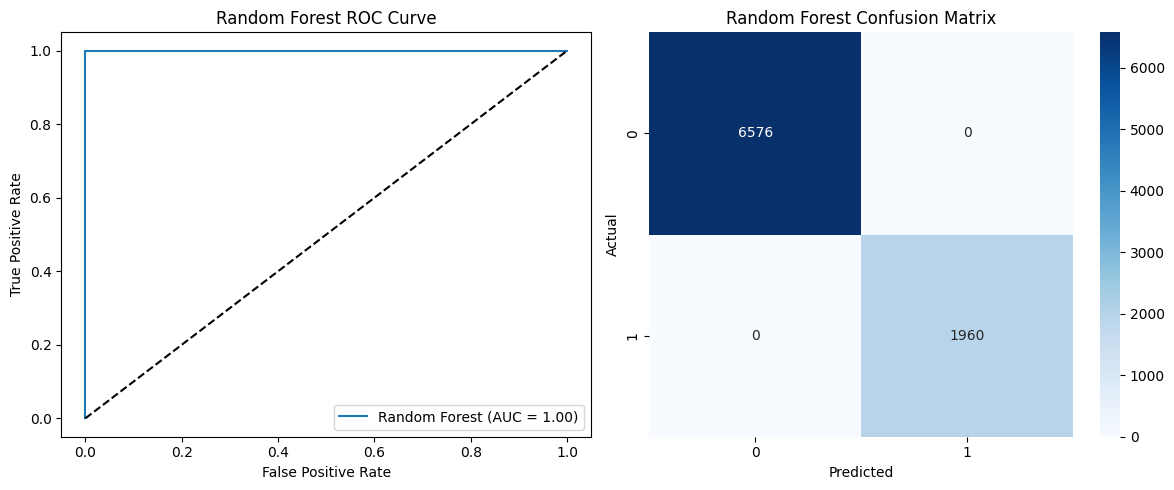


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6576
           1       1.00      1.00      1.00      1960

    accuracy                           1.00      8536
   macro avg       1.00      1.00      1.00      8536
weighted avg       1.00      1.00      1.00      8536



In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

print("\n--- Visualizing Model Performance ---")

# --- Logistic Regression Performance Visualization ---

# ROC Curve for Logistic Regression
y_pred_proba_lr = model.predict_proba(X_test_imputed)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend()

# Confusion Matrix for Logistic Regression
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

# --- Random Forest Performance Visualization ---

# ROC Curve for Random Forest
y_pred_proba_rf = rf_model.predict_proba(X_test_imputed)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()

# Confusion Matrix for Random Forest
plt.subplot(1, 2, 2)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))

In [16]:
# Save the trained Random Forest model
model_filename = 'random_forest_model.joblib'
joblib.dump(rf_model, model_filename)

print(f"Random Forest model saved to {model_filename}")

Random Forest model saved to random_forest_model.joblib
